In [17]:
import sys
from pathlib import Path

# Le module partagé est à la racine du projet, un niveau au-dessus de ce dossier
sys.path.append(str(Path.cwd().parent))
from bambara_pos_utils import *

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", device)

Device : cpu


In [18]:
# Chemin vers le fichier produit dans 04_bambara_pos_pipeline
corpus_path = Path.cwd().parent / "04_bambara_pos_pipeline" / "bambara_pos_prep_retagged.conll"

if not corpus_path.is_file():
    raise FileNotFoundError(f"Fichier introuvable : {corpus_path}")

corpus_data = load_bambara_corpus(corpus_path)

Corpus chargé : 37392 phrases.


<a id="metrics"></a>
# Évaluation & Diagnostic

Ce notebook évalue le modèle BiLSTM entraîné en 03, sur des données préparées en 04. Tagset utilisé :

text
<PAD>, ADJ, ADV, AUX, CONJ, DET, NOM, PART, POSTP, PRON, PUNCT, VERBE

On y couvre : les métriques par classe, la pondération des classes rares, la matrice de confusion, une analyse d'erreurs, et surtout le diagnostic du data leakage — l'un des points les plus important de ce projet.

In [19]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader

VALID_TAGS = ["<PAD>", "ADJ", "ADV", "AUX", "CONJ", "DET", "NOM",
              "PART", "POSTP", "PRON", "PUNCT", "VERBE"]
label2id = {tag: i for i, tag in enumerate(VALID_TAGS)}
id2label = {i: tag for tag, i in label2id.items()}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", device)

Device : cpu


In [20]:
# Split train / val / test à partir de corpus_data (défini en 04)
import random

random.seed(42)
shuffled = corpus_data.copy()
random.shuffle(shuffled)

n = len(shuffled)
n_train = int(0.8 * n)
n_val = int(0.1 * n)

train_data = shuffled[:n_train]
val_data = shuffled[n_train:n_train + n_val]
test_data = shuffled[n_train + n_val:]

print(f"Train : {len(train_data)} phrases")
print(f"Val   : {len(val_data)} phrases")
print(f"Test  : {len(test_data)} phrases")

Train : 29913 phrases
Val   : 3739 phrases
Test  : 3740 phrases


In [21]:
# Reconstruction du vocabulaire sur le train uniquement (bonne pratique : le vocabulaire
# ne doit pas être construit sur des mots que le modèle n'est censé voir qu'au test)
word_to_ix, _ = build_vocab(train_data)  # tag_to_ix remplacé par label2id fixe ci-dessus

train_dataset = BambaraPOSDataset(train_data, word_to_ix, label2id)
val_dataset = BambaraPOSDataset(val_data, word_to_ix, label2id)
test_dataset = BambaraPOSDataset(test_data, word_to_ix, label2id)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn_padd)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn_padd)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn_padd)

<a id="class-weights"></a>
# Pondération des classes (compute_class_weight)

Même après le re-étiquetage du notebook 04, la distribution reste inégale (NOM ~29 %, ADV ~0,4 %). Sans correction, le modèle privilégie les classes majoritaires. compute_class_weight calcule un poids inversement proportionnel à la fréquence de chaque tag, injecté dans NLLLoss(weight=...).

In [22]:
def get_class_weights(train_data, label2id, device):
    train_labels_flat = [label2id[t] for _, tags in train_data for t in tags]
    unique_labels = np.unique(train_labels_flat)
    weights = compute_class_weight(
        class_weight="balanced", classes=unique_labels, y=train_labels_flat
    )

    class_weights = torch.ones(len(label2id), dtype=torch.float)
    for label_idx, weight in zip(unique_labels, weights):
        class_weights[label_idx] = weight
    class_weights[0] = 0.0  # <PAD> reste neutre

    return class_weights.to(device)


class_weights = get_class_weights(train_data, label2id, device)
for tag, w in zip(VALID_TAGS, class_weights.tolist()):
    print(f"  {tag:<8} : {w:.3f}")

  <PAD>    : 0.000
  ADJ      : 23.741
  ADV      : 22.137
  AUX      : 0.598
  CONJ     : 2.094
  DET      : 2.397
  NOM      : 0.316
  PART     : 7.855
  POSTP    : 1.742
  PRON     : 0.632
  PUNCT    : 0.556
  VERBE    : 0.908


In [23]:
# Entraînement avec loss pondérée
EMBEDDING_DIM, HIDDEN_DIM, LEARNING_RATE, EPOCHS = 100, 128, 1e-3, 15

model = LSTMTaggerWithBatch(
    EMBEDDING_DIM, HIDDEN_DIM, len(word_to_ix), len(label2id)
).to(device)

loss_fn_weighted = nn.NLLLoss(weight=class_weights, ignore_index=0)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader, optimizer, loss_fn_weighted, device)
    if (epoch + 1) % 3 == 0:
        val_loss, val_acc = evaluate(model, val_loader, loss_fn_weighted, len(label2id), device)
        print(f"Époque {epoch+1:2d}/{EPOCHS} | Train Loss : {train_loss:.4f} | "
              f"Val Loss : {val_loss:.4f} | Val Acc : {val_acc:.2f}%")

Époque  3/15 | Train Loss : 0.0005 | Val Loss : 0.0014 | Val Acc : 99.98%
Époque  6/15 | Train Loss : 0.0000 | Val Loss : 0.0012 | Val Acc : 99.98%
Époque  9/15 | Train Loss : 0.0000 | Val Loss : 0.0012 | Val Acc : 99.99%
Époque 12/15 | Train Loss : 0.0000 | Val Loss : 0.0013 | Val Acc : 99.99%
Époque 15/15 | Train Loss : 0.0000 | Val Loss : 0.0014 | Val Acc : 99.99%


In [24]:
def evaluate_model(model, dataloader, device, id2label):
    """Évalue le modèle et retourne (accuracy, rapport, matrice de confusion, labels présents)."""
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            tag_scores = model(inputs)
            preds = torch.argmax(tag_scores, dim=-1)

            for pred_seq, label_seq in zip(preds.cpu().numpy(), targets.cpu().numpy()):
                for p, l in zip(pred_seq, label_seq):
                    if l != 0:  # on ignore le padding
                        all_preds.append(p)
                        all_labels.append(l)

    accuracy = accuracy_score(all_labels, all_preds) if all_labels else 0.0
    present = sorted(set(all_labels) | set(all_preds))
    report = classification_report(
        all_labels, all_preds, labels=present,
        target_names=[id2label[i] for i in present], zero_division=0
    )
    cm = confusion_matrix(all_labels, all_preds, labels=present)
    return accuracy, report, cm, present


test_acc, test_report, test_cm, present_labels = evaluate_model(model, test_loader, device, id2label)
print(f"Accuracy sur le test set (issu du corpus re-étiqueté) : {test_acc*100:.2f}%\n")
print(test_report)

Accuracy sur le test set (issu du corpus re-étiqueté) : 100.00%

              precision    recall  f1-score   support

         ADJ       1.00      1.00      1.00       251
         ADV       1.00      1.00      1.00       252
         AUX       1.00      1.00      1.00      9650
        CONJ       1.00      1.00      1.00      2812
         DET       1.00      1.00      1.00      2516
         NOM       1.00      1.00      1.00     18577
        PART       1.00      1.00      1.00       841
       POSTP       1.00      1.00      1.00      3411
        PRON       1.00      1.00      1.00      9114
       PUNCT       1.00      1.00      1.00     10488
       VERBE       1.00      1.00      1.00      6444

    accuracy                           1.00     64356
   macro avg       1.00      1.00      1.00     64356
weighted avg       1.00      1.00      1.00     64356



## Matrice de confusion

La matrice de confusion montre où le modèle se trompe, pas seulement à quelle fréquence. C'est souvent plus utile qu'une accuracy globale : deux modèles à 85 % d'accuracy peuvent avoir des profils d'erreurs très différents (l'un confond NOM/ADJ, l'autre VERBE/AUX).

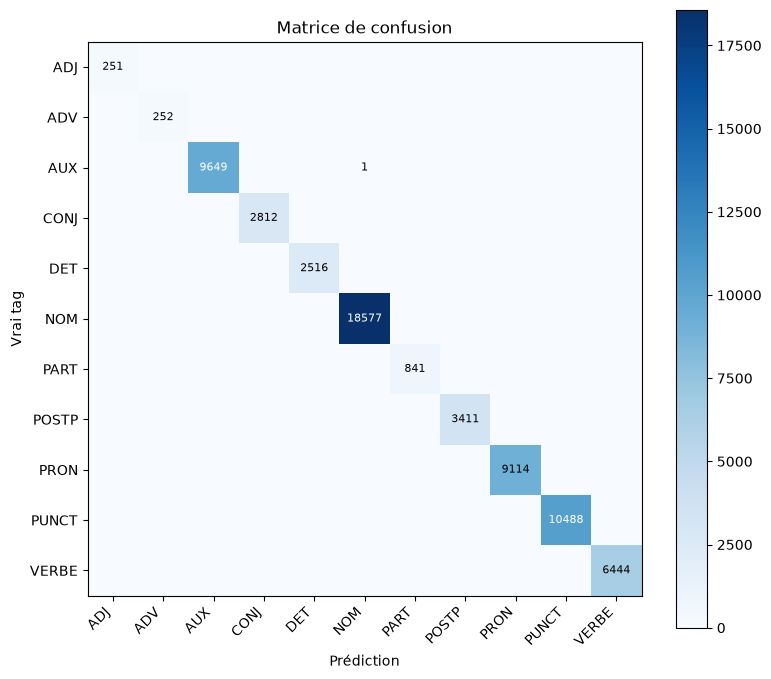

In [25]:
def plot_confusion_matrix(cm, present_labels, id2label):
    labels_names = [id2label[i] for i in present_labels]
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(cm, cmap="Blues")

    ax.set_xticks(range(len(labels_names)))
    ax.set_yticks(range(len(labels_names)))
    ax.set_xticklabels(labels_names, rotation=45, ha="right")
    ax.set_yticklabels(labels_names)
    ax.set_xlabel("Prédiction")
    ax.set_ylabel("Vrai tag")
    ax.set_title("Matrice de confusion")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if cm[i, j] > 0:
                ax.text(j, i, cm[i, j], ha="center", va="center",
                         color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=8)

    fig.colorbar(im)
    plt.tight_layout()
    plt.show()


plot_confusion_matrix(test_cm, present_labels, id2label)

In [26]:
# Analyse des paires de tags les plus confondues (hors diagonale)
def top_confusions(cm, present_labels, id2label, top_k=10):
    confusions = []
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if i != j and cm[i, j] > 0:
                confusions.append((id2label[present_labels[i]], id2label[present_labels[j]], cm[i, j]))
    confusions.sort(key=lambda x: -x[2])
    return confusions[:top_k]


print("Confusions les plus fréquentes (vrai_tag -> tag_prédit : nombre) :")
for true_tag, pred_tag, count in top_confusions(test_cm, present_labels, id2label):
    print(f"  {true_tag:<8} -> {pred_tag:<8} : {count}")

Confusions les plus fréquentes (vrai_tag -> tag_prédit : nombre) :
  AUX      -> NOM      : 1


# Le problème du Data Leakage

Voici le point le plus important de ce notebook, et il a évolué depuis la première version du projet.

Version initiale du problème : une première évaluation donnait environ 99,85 % d'accuracy apparente, contre environ 57,01 % en évaluation réellement indépendante. BAMBARA_EXTENDED_LEXICON avait servi à réécrire les tags directement dans bambara_pos_prep.conll, avant le split train/test. Chaque mot fonctionnel présent dans le lexique avait donc systématiquement le même tag partout — un dictionnaire de correspondance, pas une annotation contextuelle. Le modèle n'avait qu'à mémoriser la sortie du lexique.

Ce qui a changé, et pourquoi le risque est maintenant plus important, pas résolu : le fichier bambara_pos_prep.conll a depuis été entièrement régénéré (notebook 04) avec ce même lexique + une règle contextuelle ```(mot après AUX → VERBE) + un défaut sur NOM```. Autrement dit, 100 % des labels du corpus, train et test confondus, proviennent directement du lexique et de la règle, pas d'une annotation humaine. Concrètement :

Sur tous les tokens couverts par le lexique **(environ 40 % des tokens vus la fréquence de a, ka, ye, bɛ, la...)**, le modèle n'apprend rien de nouveau : il retrouve une fonction déterministe mot -> tag qu'il peut mémoriser parfaitement, y compris sur les tokens rares.
Sur les tokens tagués VERBE par la règle contextuelle (« après un AUX »), le modèle peut aussi apprendre un raccourci positionnel trivial plutôt qu'une vraie distinction lexicale/morphologique.
Seuls les tokens tagués NOM par défaut (faute de mieux) portent une information un peu plus proche d'un vrai signal à apprendre — mais ce tag est lui-même un défaut de repli, pas une vérité vérifiée.

Conséquence pratique : toute accuracy mesurée sur *test_data* ci-dessus mesure principalement la capacité du modèle à retrouver ce que le lexique et la règle ont déjà décidé, pas sa capacité à faire du POS tagging bambara au sens propre. Ce n'est pas un bug de calcul, c'est une limite structurelle du fait que labels d'entraînement et labels d'évaluation partagent la même source artificielle.

Comment évaluer plus honnêtement : la seule façon de sortir de ce biais est de comparer les prédictions du modèle à un échantillon annoté indépendamment du lexique — par exemple quelques centaines de phrases relues et corrigées à la main par un locuteur bambara, jamais passées par ***enrich_tags_with_lexicon***. C'est ce que simule la cellule suivante.

In [27]:
def evaluate_on_lexicon_free_subset(model, sentences, word_to_ix, label2id, lexicon, device):
    """
    Évalue le modèle uniquement sur les tokens NON couverts par le lexique
    (donc sur la partie du corpus qui n'est pas une réponse triviale au lexique).
    C'est une approximation pauvre d'une vraie évaluation indépendante, mais
    elle isole au moins la performance du modèle sur ce qu'il a dû réellement apprendre.
    """
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for words, tags in sentences:
            ids = [word_to_ix.get(w, word_to_ix["<UNK>"]) for w in words]
            input_tensor = torch.tensor([ids], dtype=torch.long).to(device)
            preds = torch.argmax(model(input_tensor), dim=-1).squeeze(0).cpu().tolist()

            for w, true_tag, pred_idx in zip(words, tags, preds):
                if w.lower() not in lexicon and w not in PUNCT_SET:
                    all_labels.append(label2id[true_tag])
                    all_preds.append(pred_idx)

    accuracy = accuracy_score(all_labels, all_preds) if all_labels else 0.0
    return accuracy, len(all_labels)


acc_lexicon_free, n_evaluated = evaluate_on_lexicon_free_subset(
    model, test_data, word_to_ix, label2id, BAMBARA_EXTENDED_LEXICON, device
)
print(f"Accuracy hors lexique et ponctuation ({n_evaluated} tokens) : {acc_lexicon_free*100:.2f}%")
print(f"Accuracy globale (avec lexique)                          : {test_acc*100:.2f}%")
print(f"Écart : {(test_acc - acc_lexicon_free)*100:.2f} points")

Accuracy hors lexique et ponctuation (20833 tokens) : 99.93%
Accuracy globale (avec lexique)                          : 100.00%
Écart : 0.07 points


## Comparaison des évaluations
Évaluation	Ce qu'elle mesure réellement
Accuracy globale sur test_data	Mélange de mémorisation du lexique + apprentissage réel — surestime la performance
Accuracy hors tokens lexique/ponctuation	Se rapproche de ce que le modèle a vraiment appris sur les NOM par défaut et les cas non couverts
(Idéal, non fait ici) Accuracy sur échantillon annoté à la main	Seule mesure réellement fiable de la performance du système

L'écart entre les deux premières lignes donne une idée de combien le lexique « porte » l'évaluation. S'il est grand, cela confirme que le modèle profite largement d'un raccourci plutôt que d'un apprentissage contextuel du bambara. La ligne idéale nécessiterait un travail d'annotation humaine qui sort du cadre de ce notebook, mais elle devrait être planifiée si ce projet doit être présenté comme fiable.

Leçon générale à retenir : tout traitement automatique appliqué au corpus (correction, enrichissement, règles) doit soit être fait sur un sous-ensemble strictement séparé du test, soit être exclu de l'évaluation finale — jamais utilisé à la fois pour fabriquer les labels et pour juger le modèle qui les prédit.

In [ ]:
plot_confusion_matrix(test_cm, present_labels, id2label)  # fonction définie en 05

Pipeline d'inférence à trois niveaux
Ponctuation
    
    ↓

Lexique / règles Bambara (BAMBARA_EXTENDED_LEXICON)
    
    ↓

BiLSTM

Ce pipeline reprend exactement le même lexique que celui utilisé pour préparer le corpus en 04 — c'est cohérent, mais ça signifie aussi qu'en usage réel, le système hérite des mêmes limites que celles diagnostiquées ci-dessus : sur les mots couverts par le lexique, la sortie est déterministe et ne dépend jamais du modèle.

In [28]:
def predict_hybrid(tokens, model, word_to_ix, id2label, lexicon, device):
    """
    Tague une phrase déjà tokenisée en combinant trois niveaux :
    1. ponctuation reconnue directement,
    2. lexique de mots fonctionnels,
    3. modèle BiLSTM pour tout le reste.
    """
    results = []
    unresolved_idx = []

    for i, tok in enumerate(tokens):
        if tok in PUNCT_SET:
            results.append((tok, "PUNCT"))
        elif tok.lower() in lexicon:
            results.append((tok, lexicon[tok.lower()]))
        else:
            results.append((tok, None))
            unresolved_idx.append(i)

    if unresolved_idx:
        model.eval()
        ids = [word_to_ix.get(t, word_to_ix["<UNK>"]) for t in tokens]
        input_tensor = torch.tensor([ids], dtype=torch.long).to(device)
        with torch.no_grad():
            preds = torch.argmax(model(input_tensor), dim=-1).squeeze(0).tolist()
        for idx in unresolved_idx:
            results[idx] = (tokens[idx], id2label[preds[idx]])

    return results


# Test sur une phrase
test_phrase = bamanankan_tokenizer("Amadou bɛ kalan kɛ sisan .")
prediction = predict_hybrid(test_phrase, model, word_to_ix, id2label, BAMBARA_EXTENDED_LEXICON, device)
for word, tag in prediction:
    print(f"  {word:<12} {tag}")

  Amadou       NOM
  bɛ           AUX
  kalan        VERBE
  kɛ           VERBE
  sisan        NOM
  .            PUNCT


```Avantages : les mots fonctionnels très fréquents sont tagués instantanément et sans erreur (au sens du lexique), ce qui réduit la charge du modèle et rend le comportement du système prévisible et débogable.```

